# Validation: GALsPeCtrA ↔ L-GALAXIES 2020

Compares synthetic SDSS photometry from PCA-reconstructed SEDs against the magnitudes
stored directly in the L-GALAXIES catalog.

Both pipelines use the **same BC03 library** (Chabrier IMF, Bruzual & Charlot 2003),
and GALsPeCtrA applies the **same two-component dust model** as L-GALAXIES
(Mathis 1983 ISM attenuation + birth-cloud attenuation for stars younger than 10 Myr).

Two comparisons are made:
- **Intrinsic SED** (`synth_mag_*`) vs L-GALAXIES `Mag` — dust-free absolute magnitudes
- **Dust-attenuated SED** (`synth_magdust_*`) vs L-GALAXIES `MagDust`

Residual scatter in the dust comparison comes from stochastic birth-cloud
sampling (μ drawn once per galaxy from Gaussian(0.3, 0.2)).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
LGAL_ROOT    = PROJECT_ROOT.parent / 'L-GALAXIES' / 'LGalaxies2020_PublicRepository-master'

# Load outputs
G = np.load(
    LGAL_ROOT / 'output/samples/Planck_Mil-II_snapshots_default_test1_z0.00-0.00_All.npy',
    allow_pickle=True
)
synth = np.load(PROJECT_ROOT / 'data/lgalaxies_sed_coeffs_bc03_MRII_test1.npz')

# L-GALAXIES stored magnitudes
mag     = G['Mag']     # (N, 5) intrinsic absolute AB magnitudes, SDSS ugriz
magdust = G['MagDust'] # (N, 5) dust-attenuated

# Valid galaxies (sentinel = 99.0)
valid      = mag[:, 2] < 90.0
valid_dust = magdust[:, 2] < 90.0
print(f'Valid galaxies (Mag):     {valid.sum():,} / {len(G):,} ({100*valid.mean():.1f}%)')
print(f'Valid galaxies (MagDust): {valid_dust.sum():,} / {len(G):,} ({100*valid_dust.mean():.1f}%)')

# L-GALAXIES bands
lgal_u, lgal_g, lgal_r, lgal_i, lgal_z = [mag[valid, k]          for k in range(5)]
lgdu_u, lgdu_g, lgdu_r, lgdu_i, lgdu_z = [magdust[valid_dust, k] for k in range(5)]

# Synthetic (intrinsic)
sy_u = synth['synth_mag_u'][valid]; sy_g = synth['synth_mag_g'][valid]
sy_r = synth['synth_mag_r'][valid]; sy_i = synth['synth_mag_i'][valid]
sy_z = synth['synth_mag_z'][valid]

# Synthetic (dust-attenuated)
sd_u = synth['synth_magdust_u'][valid_dust]; sd_g = synth['synth_magdust_g'][valid_dust]
sd_r = synth['synth_magdust_r'][valid_dust]; sd_i = synth['synth_magdust_i'][valid_dust]
sd_z = synth['synth_magdust_z'][valid_dust]

bands = ['u', 'g', 'r', 'i', 'z']
pca_coeffs = synth['pca_coeffs']   # (N_gal, 50)

Valid galaxies (Mag):     9,923 / 12,601 (78.7%)
Valid galaxies (MagDust): 9,828 / 12,601 (78.0%)


## 0. Magnitude Distribution Comparison

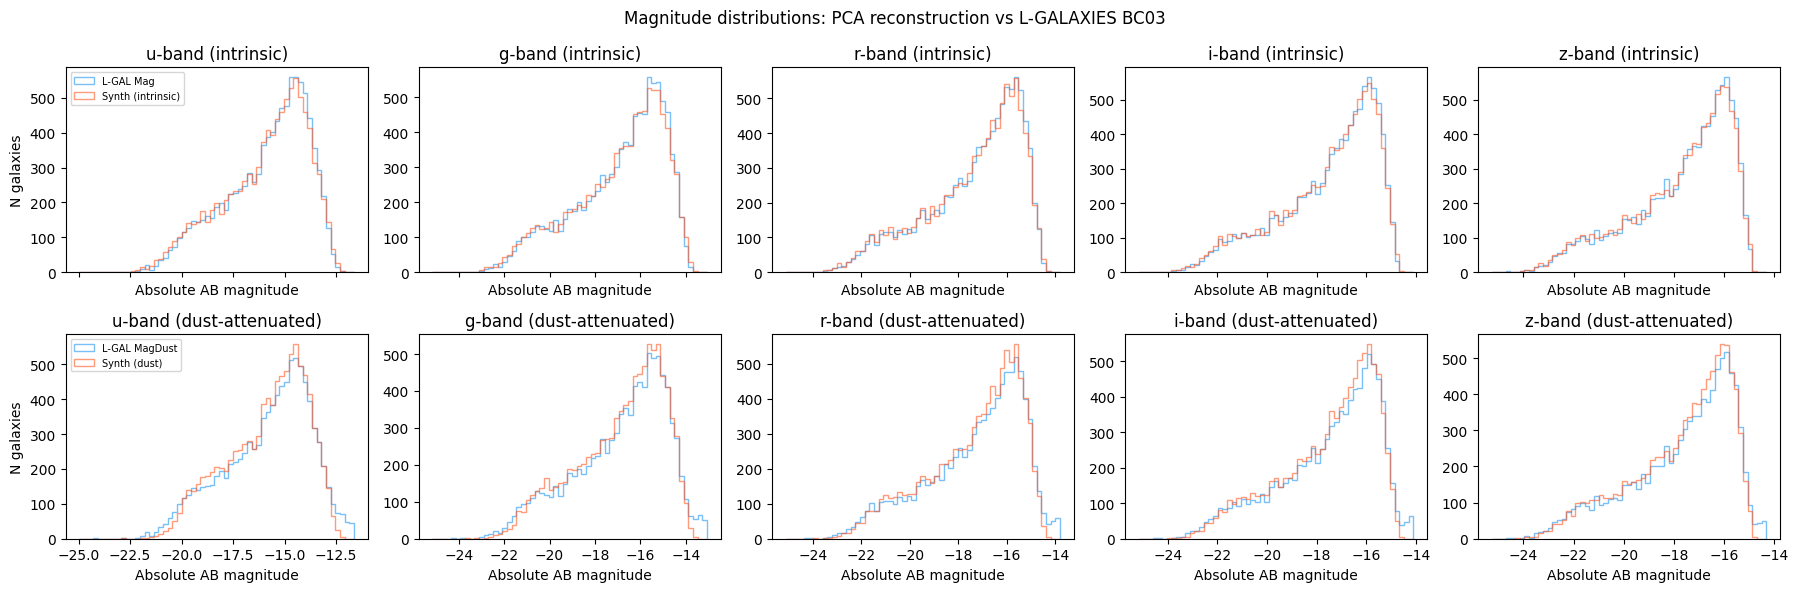

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharex='col')

sy_mags   = [sy_u, sy_g, sy_r, sy_i, sy_z]
sd_mags   = [sd_u, sd_g, sd_r, sd_i, sd_z]
lgal_mags = [lgal_u, lgal_g, lgal_r, lgal_i, lgal_z]
lgdu_mags = [lgdu_u, lgdu_g, lgdu_r, lgdu_i, lgdu_z]

for j, (band, sy, sd, lg, ld) in enumerate(zip(bands, sy_mags, sd_mags, lgal_mags, lgdu_mags)):
    lo = min(lg.min(), sy.min()) - 0.5
    hi = max(lg.max(), sy.max()) + 0.5
    bins = np.linspace(lo, hi, 60)

    ax = axes[0, j]
    ax.hist(lg, bins=bins, alpha=0.6, label='L-GAL Mag',         color='#2196F3', histtype = 'step')
    ax.hist(sy, bins=bins, alpha=0.6, label='Synth (intrinsic)', color='#FF5722', histtype = 'step')
    ax.set_title(f'{band}-band (intrinsic)')
    ax.set_xlabel('Absolute AB magnitude')
    if j == 0:
        ax.set_ylabel('N galaxies')
        ax.legend(fontsize=7)

    ax = axes[1, j]
    ax.hist(ld, bins=bins, alpha=0.6, label='L-GAL MagDust', color='#2196F3', histtype = 'step')
    ax.hist(sd, bins=bins, alpha=0.6, label='Synth (dust)',  color='#FF5722', histtype = 'step')
    ax.set_title(f'{band}-band (dust-attenuated)')
    ax.set_xlabel('Absolute AB magnitude')
    if j == 0:
        ax.set_ylabel('N galaxies')
        ax.legend(fontsize=7)

plt.suptitle('Magnitude distributions: PCA reconstruction vs L-GALAXIES BC03', fontsize=12)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/validation_mag_dists.png', dpi=150, bbox_inches='tight')
plt.show()

## 1. Absolute Magnitude Comparison (Intrinsic)

Direct 1:1 comparison of synthetic vs L-GALAXIES `Mag` in each band.
Pearson r ≈ 1.000 and offset < 0.03 mag confirms the training age bug is fixed.

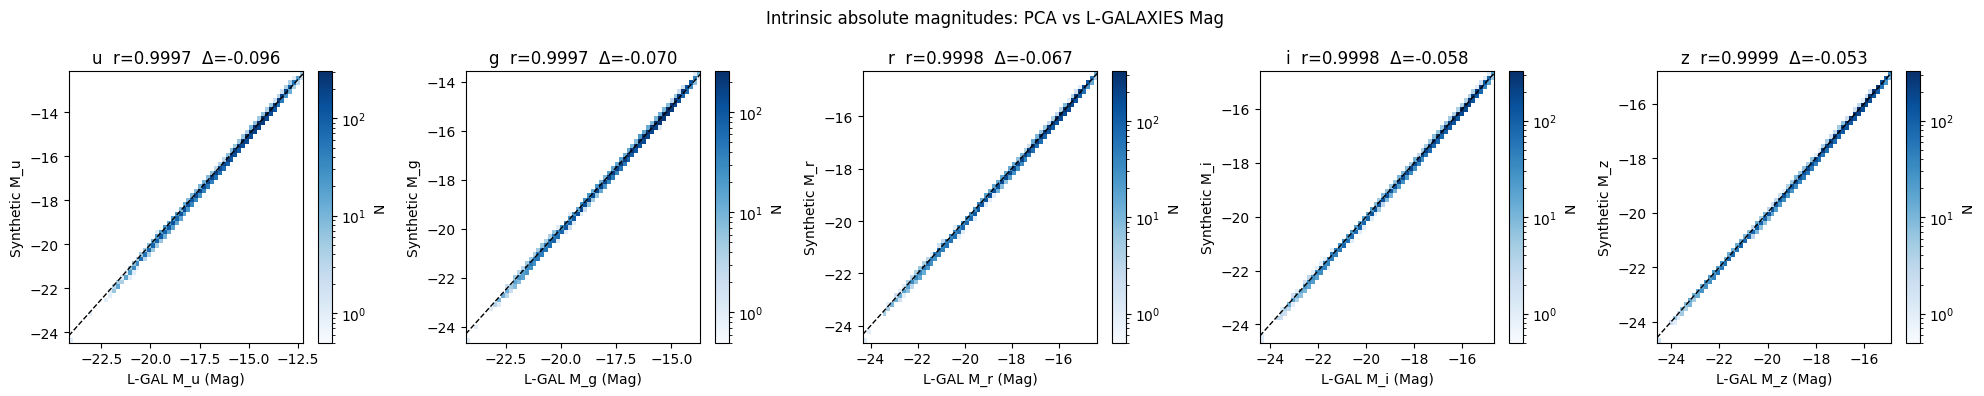

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, band, lg, sy in zip(axes, bands, lgal_mags, sy_mags):
    h, xe, ye = np.histogram2d(lg, sy, bins=60)
    im = ax.imshow(
        h.T, origin='lower',
        extent=[xe[0], xe[-1], ye[0], ye[-1]],
        aspect='auto', cmap='Blues', norm=mcolors.LogNorm(vmin=0.5)
    )
    plt.colorbar(im, ax=ax, label='N')
    lo, hi = xe[0], xe[-1]
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='1:1')
    r      = np.corrcoef(lg, sy)[0, 1]
    offset = np.median(sy - lg)
    ax.set_xlabel(f'L-GAL M_{band} (Mag)')
    ax.set_ylabel(f'Synthetic M_{band}')
    ax.set_title(f'{band}  r={r:.4f}  Δ={offset:+.3f}')

plt.suptitle('Intrinsic absolute magnitudes: PCA vs L-GALAXIES Mag', fontsize=12)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/validation_abs_mag.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Absolute Magnitude Comparison (Dust-Attenuated)

Synthetic dust-attenuated magnitudes vs L-GALAXIES `MagDust`.
Scatter (~0.3 mag) comes from stochastic birth-cloud sampling (μ per galaxy).

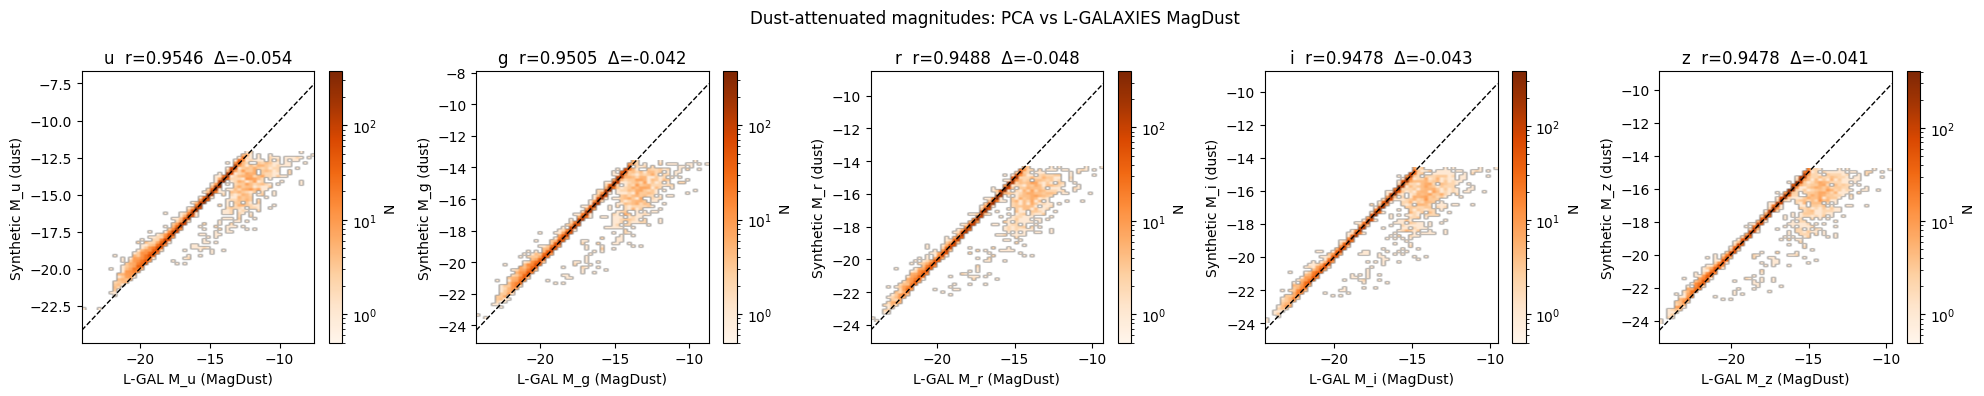

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, band, ld, sd in zip(axes, bands, lgdu_mags, sd_mags):
    h, xe, ye = np.histogram2d(ld, sd, bins=60)
    im = ax.imshow(
        h.T, origin='lower',
        extent=[xe[0], xe[-1], ye[0], ye[-1]],
        aspect='auto', cmap='Oranges', norm=mcolors.LogNorm(vmin=0.5)
    )
    plt.colorbar(im, ax=ax, label='N')
    lo, hi = xe[0], xe[-1]
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='1:1')
    r      = np.corrcoef(ld, sd)[0, 1]
    offset = np.median(sd - ld)
    ax.set_xlabel(f'L-GAL M_{band} (MagDust)')
    ax.set_ylabel(f'Synthetic M_{band} (dust)')
    ax.set_title(f'{band}  r={r:.4f}  Δ={offset:+.3f}')

plt.suptitle('Dust-attenuated magnitudes: PCA vs L-GALAXIES MagDust', fontsize=12)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/validation_dust_mag.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Colour–Colour Comparison

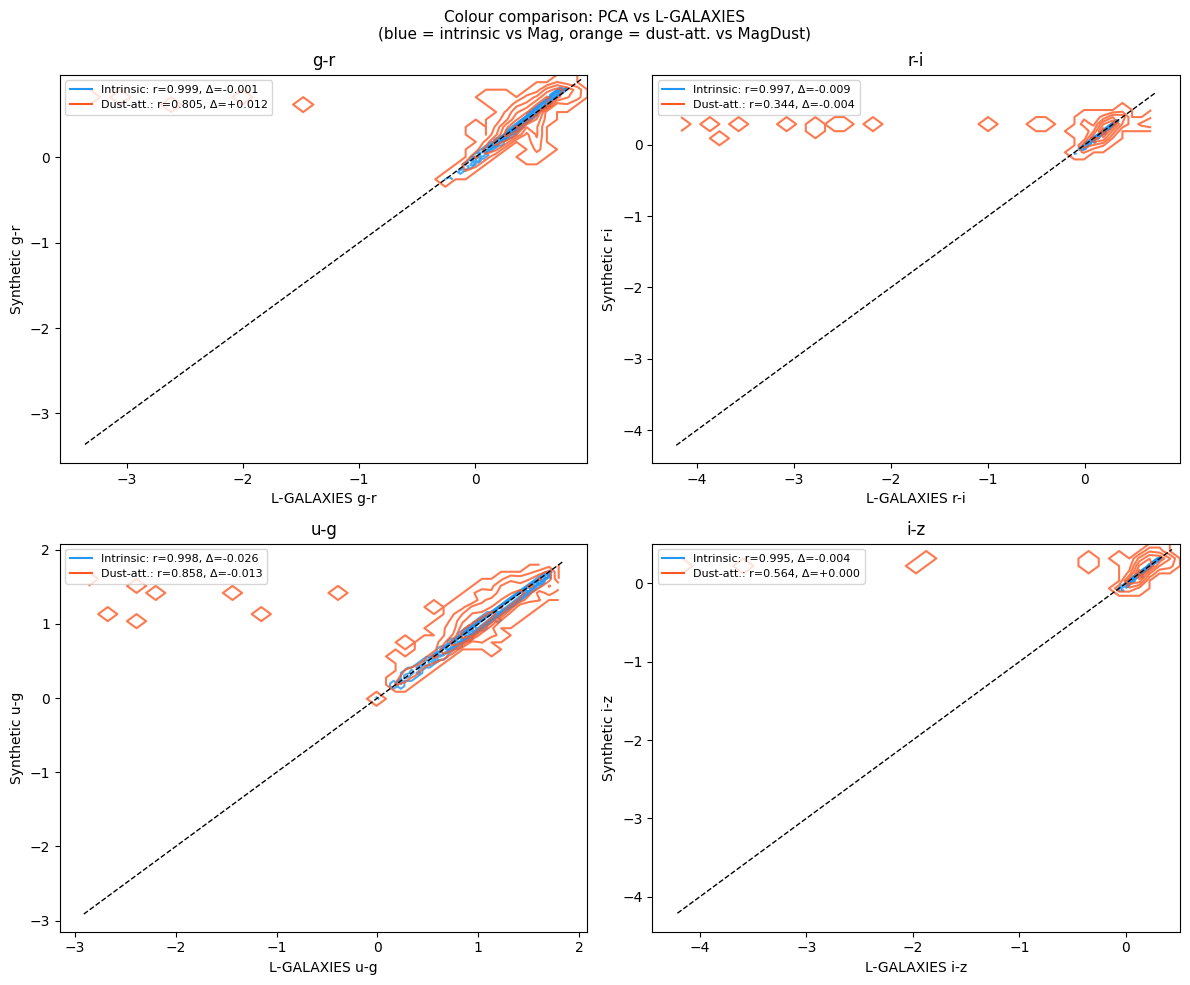

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

colour_pairs = [
    (lgal_g - lgal_r, sy_g - sy_r, lgdu_g - lgdu_r, sd_g - sd_r, 'g-r'),
    (lgal_r - lgal_i, sy_r - sy_i, lgdu_r - lgdu_i, sd_r - sd_i, 'r-i'),
    (lgal_u - lgal_g, sy_u - sy_g, lgdu_u - lgdu_g, sd_u - sd_g, 'u-g'),
    (lgal_i - lgal_z, sy_i - sy_z, lgdu_i - lgdu_z, sd_i - sd_z, 'i-z'),
]

for ax, (lgal_c, sy_c, lgdu_c, sd_c, label) in zip(axes.flat, colour_pairs):
    for lc, sc, col, lbl in [
        (lgal_c, sy_c, '#2196F3', 'Intrinsic'),
        (lgdu_c, sd_c, '#FF5722', 'Dust-att.'),
    ]:
        lo = min(lc.min(), sc.min())
        hi = max(lc.max(), sc.max())
        h, xe, ye = np.histogram2d(lc, sc, bins=50, range=[[lo, hi], [lo, hi]])
        r      = np.corrcoef(lc, sc)[0, 1]
        offset = np.median(sc - lc)
        ax.contour(0.5*(xe[:-1]+xe[1:]), 0.5*(ye[:-1]+ye[1:]), np.log1p(h.T),
                   levels=6, colors=[col], alpha=0.8)
        ax.plot([], [], color=col, label=f'{lbl}: r={r:.3f}, Δ={offset:+.3f}')

    lo = min(lgal_c.min(), lgdu_c.min())
    hi = max(lgal_c.max(), lgdu_c.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    ax.set_xlabel(f'L-GALAXIES {label}')
    ax.set_ylabel(f'Synthetic {label}')
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.suptitle('Colour comparison: PCA vs L-GALAXIES\n'
             '(blue = intrinsic vs Mag, orange = dust-att. vs MagDust)', fontsize=11)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/validation_colours.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Colour–Magnitude Diagram

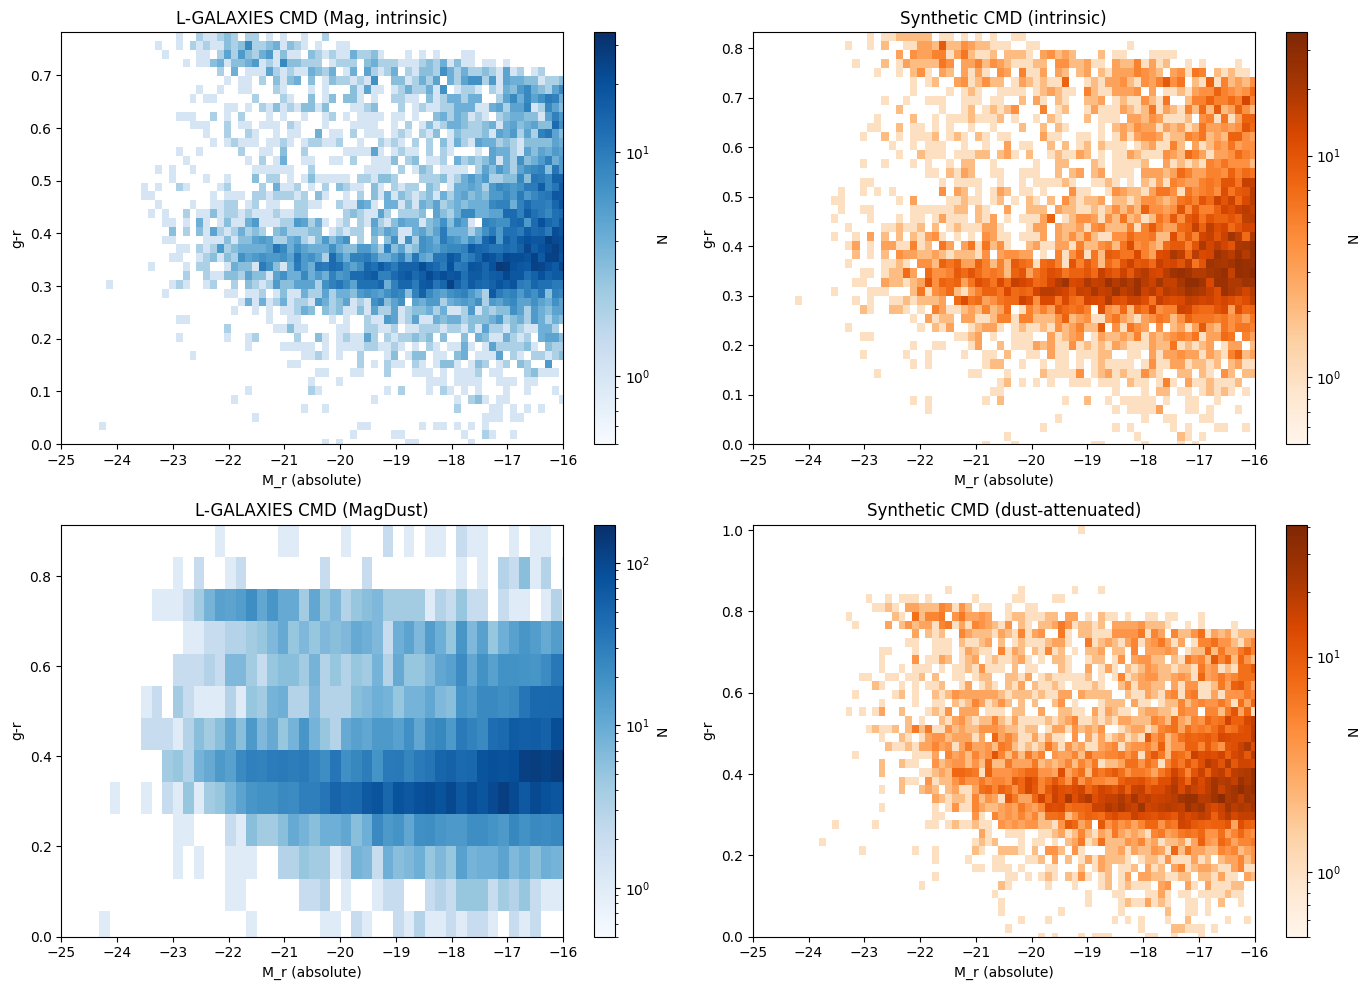

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (r_mag, gr_colour, title, cmap) in enumerate([
    (lgal_r, lgal_g - lgal_r, 'L-GALAXIES CMD (Mag, intrinsic)',    'Blues'),
    (sy_r,   sy_g   - sy_r,   'Synthetic CMD (intrinsic)',            'Oranges'),
    (lgdu_r, lgdu_g - lgdu_r, 'L-GALAXIES CMD (MagDust)',             'Blues'),
    (sd_r,   sd_g   - sd_r,   'Synthetic CMD (dust-attenuated)',       'Oranges'),
]):
    ax = axes[row // 2, row % 2]
    h, xe, ye = np.histogram2d(r_mag, gr_colour, bins=(80, 60))
    im = ax.imshow(h.T, origin='lower',
                   extent=[xe[0], xe[-1], ye[0], ye[-1]],
                   aspect='auto', cmap=cmap, norm=mcolors.LogNorm(vmin=0.5))
    plt.colorbar(im, ax=ax, label='N')
    ax.set_xlim(-25, -16)
    ax.set_ylim(-0.)
    ax.set_xlabel('M_r (absolute)')
    ax.set_ylabel('g-r')
    ax.set_title(title)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/validation_cmd.png', dpi=150, bbox_inches='tight')
plt.show()

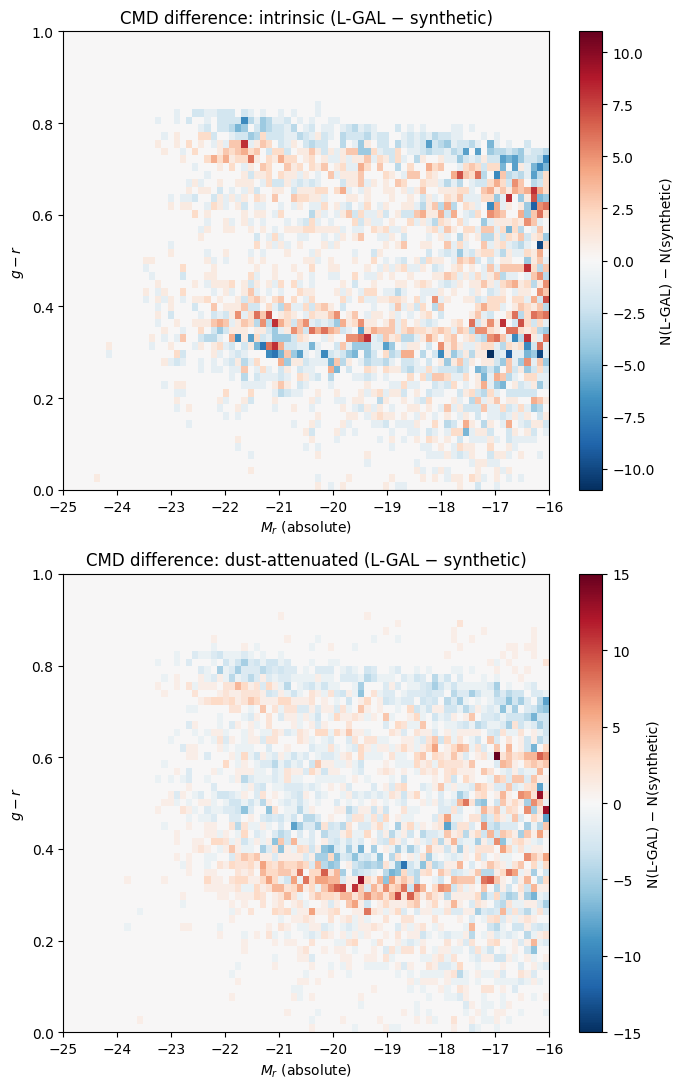

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(7, 11))

# Show the CMD count-difference (L-GAL minus synthetic) for intrinsic
# and dust-attenuated photometry.  Positive (blue) = L-GAL excess;
# negative (red) = synthetic excess.
for row, (r_mag, lgal_gr, sy_gr, title) in enumerate([
    (lgal_r, lgal_g - lgal_r, sy_g - sy_r,   'CMD difference: intrinsic (L-GAL − synthetic)'),
    (sd_r,   lgdu_g - lgdu_r, sd_g - sd_r,   'CMD difference: dust-attenuated (L-GAL − synthetic)'),
]):
    grid_bin = (np.linspace(-25, -16, 80), np.linspace(0, 1, 60))
    ax = axes[row]
    h_lgal, xe, ye = np.histogram2d(r_mag,    lgal_gr, bins=grid_bin)
    h_sy,   _,  _  = np.histogram2d(r_mag,    sy_gr,   bins=grid_bin)
    diff = (h_lgal - h_sy).T

    vmax = max(1.0, np.abs(diff).max())
    im = ax.imshow(diff, origin='lower',
                   extent=[xe[0], xe[-1], ye[0], ye[-1]],
                   aspect='auto', cmap='RdBu_r',
                   vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax, label='N(L-GAL) − N(synthetic)')
    ax.set_xlim(-25, -16)
    ax.set_ylim(0, 1)
    ax.set_xlabel('$M_r$ (absolute)')
    ax.set_ylabel('$g-r$')
    ax.set_title(title)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/validation_cmd_diff.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. PCA Coefficient Distributions

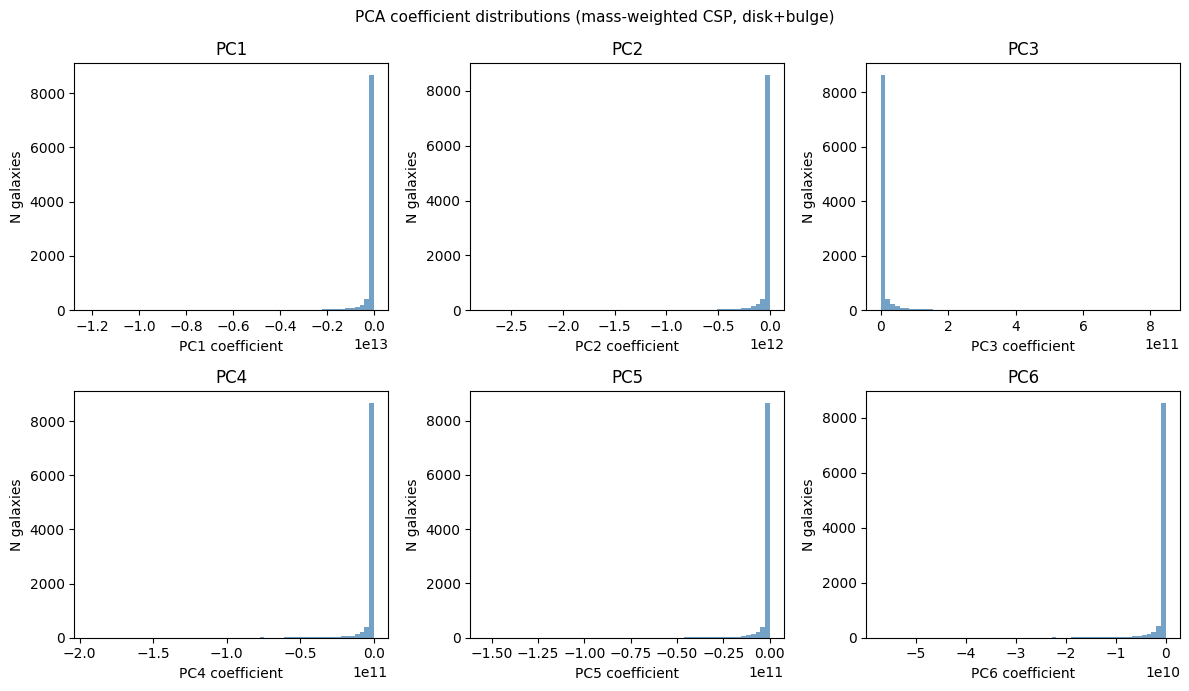

In [9]:
pca_valid = pca_coeffs[valid]
n_show = 6

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for i, ax in enumerate(axes.flat):
    ax.hist(pca_valid[:, i], bins=60, color='steelblue', edgecolor='none', alpha=0.75)
    ax.set_xlabel(f'PC{i+1} coefficient')
    ax.set_ylabel('N galaxies')
    ax.set_title(f'PC{i+1}')
plt.suptitle('PCA coefficient distributions (mass-weighted CSP, disk+bulge)', fontsize=11)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/validation_pca_dists.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Stellar Mass vs. Colour

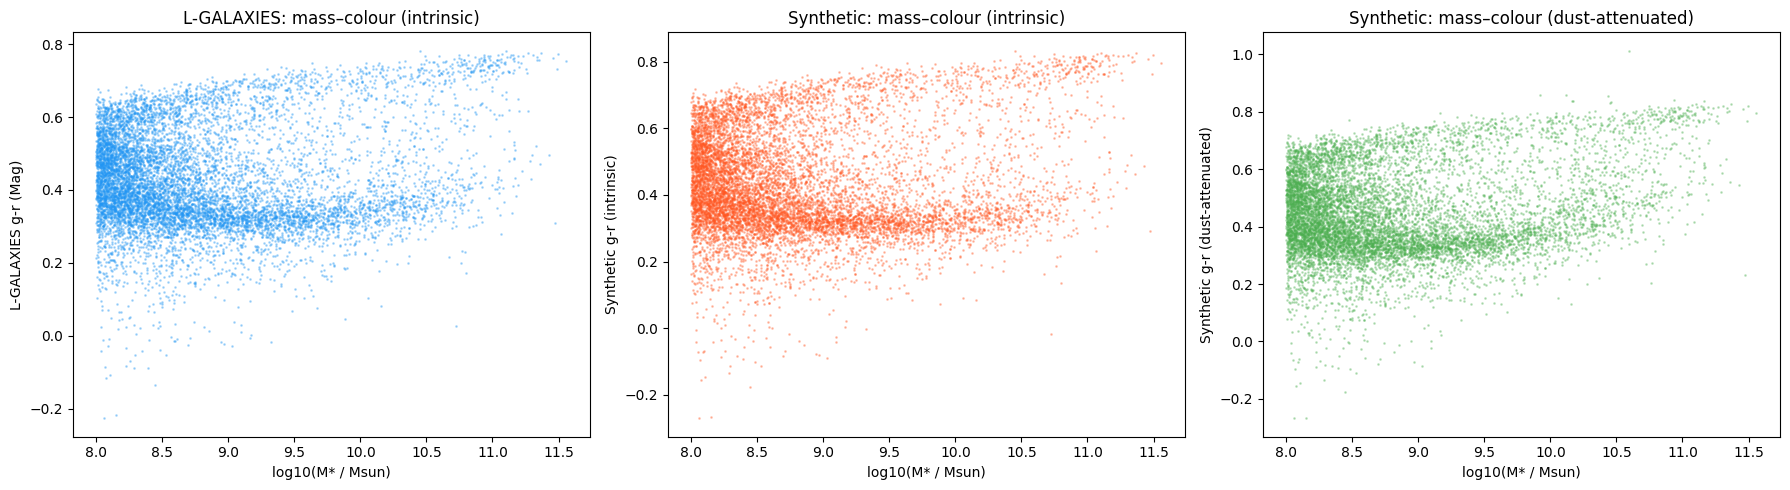

Pearson r (logM* vs g-r)  L-GALAXIES: 0.106   Synthetic: 0.088   Synthetic+dust: 0.207


In [10]:
log_mstar      = np.log10(G['StellarMass'][valid]      + 1e-10)
log_mstar_dust = np.log10(G['StellarMass'][valid_dust]  + 1e-10)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.scatter(log_mstar, lgal_g - lgal_r, s=1, alpha=0.3, c='#2196F3', rasterized=True)
ax.set_xlabel('log10(M* / Msun)')
ax.set_ylabel('L-GALAXIES g-r (Mag)')
ax.set_title('L-GALAXIES: mass–colour (intrinsic)')

ax = axes[1]
ax.scatter(log_mstar, sy_g - sy_r, s=1, alpha=0.3, c='#FF5722', rasterized=True)
ax.set_xlabel('log10(M* / Msun)')
ax.set_ylabel('Synthetic g-r (intrinsic)')
ax.set_title('Synthetic: mass–colour (intrinsic)')

ax = axes[2]
ax.scatter(log_mstar_dust, sd_g - sd_r, s=1, alpha=0.3, c='#4CAF50', rasterized=True)
ax.set_xlabel('log10(M* / Msun)')
ax.set_ylabel('Synthetic g-r (dust-attenuated)')
ax.set_title('Synthetic: mass–colour (dust-attenuated)')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/validation_mass_colour.png', dpi=150, bbox_inches='tight')
plt.show()

r_lgal  = np.corrcoef(log_mstar, lgal_g - lgal_r)[0, 1]
r_synth = np.corrcoef(log_mstar, sy_g - sy_r)[0, 1]
r_dust  = np.corrcoef(log_mstar_dust, sd_g - sd_r)[0, 1]
print(f'Pearson r (logM* vs g-r)  L-GALAXIES: {r_lgal:.3f}   '
      f'Synthetic: {r_synth:.3f}   Synthetic+dust: {r_dust:.3f}')

## 7. Summary Statistics

In [11]:
print('='*70)
print(f'Sample: {valid.sum():,} valid (Mag), {valid_dust.sum():,} valid (MagDust)')
print()

sy_all = [sy_u, sy_g, sy_r, sy_i, sy_z]
sd_all = [sd_u, sd_g, sd_r, sd_i, sd_z]
bi_map = {b: i for i, b in enumerate(bands)}

print('Intrinsic absolute magnitudes (synth vs L-GALAXIES Mag):')
print(f'{"Band":<5} {"LGal med":>9} {"Synth med":>9} {"Offset":>8} {"Scatter":>8} {"Pearson r":>10}')
print('-'*54)
for bi, (band, sy) in enumerate(zip(bands, sy_all)):
    lg   = mag[valid, bi]
    off  = np.median(sy - lg)
    scat = np.std(sy - lg)
    r    = np.corrcoef(lg, sy)[0, 1]
    print(f'{band:<5} {np.median(lg):>9.3f} {np.median(sy):>9.3f} {off:>+8.3f} {scat:>8.3f} {r:>10.4f}')

print()
print('Dust-attenuated magnitudes (synth vs L-GALAXIES MagDust):')
print(f'{"Band":<5} {"LGal med":>9} {"Synth med":>9} {"Offset":>8} {"Scatter":>8} {"Pearson r":>10}')
print('-'*54)
for bi, (band, sd) in enumerate(zip(bands, sd_all)):
    ld   = magdust[valid_dust, bi]
    off  = np.median(sd - ld)
    scat = np.std(sd - ld)
    r    = np.corrcoef(ld, sd)[0, 1]
    print(f'{band:<5} {np.median(ld):>9.3f} {np.median(sd):>9.3f} {off:>+8.3f} {scat:>8.3f} {r:>10.4f}')

print()
print('Intrinsic colours (synth vs L-GALAXIES Mag):')
print(f'{"Colour":<8} {"LGal med":>9} {"Synth med":>9} {"Offset":>8} {"Scatter":>8} {"Pearson r":>10}')
print('-'*58)
sy_map = dict(zip(bands, sy_all))
for b1, b2 in [('g','r'), ('r','i'), ('u','g'), ('i','z')]:
    lc   = mag[valid, bi_map[b1]] - mag[valid, bi_map[b2]]
    sc   = sy_map[b1] - sy_map[b2]
    off  = np.median(sc - lc)
    scat = np.std(sc - lc)
    r    = np.corrcoef(lc, sc)[0, 1]
    print(f'{b1}-{b2:<6} {np.median(lc):>9.3f} {np.median(sc):>9.3f} {off:>+8.3f} {scat:>8.3f} {r:>10.4f}')

print()
print('Dust-attenuated colours (synth vs L-GALAXIES MagDust):')
print(f'{"Colour":<8} {"LGal med":>9} {"Synth med":>9} {"Offset":>8} {"Scatter":>8} {"Pearson r":>10}')
print('-'*58)
sd_map = dict(zip(bands, sd_all))
for b1, b2 in [('g','r'), ('r','i'), ('u','g'), ('i','z')]:
    lc   = magdust[valid_dust, bi_map[b1]] - magdust[valid_dust, bi_map[b2]]
    sc   = sd_map[b1] - sd_map[b2]
    off  = np.median(sc - lc)
    scat = np.std(sc - lc)
    r    = np.corrcoef(lc, sc)[0, 1]
    print(f'{b1}-{b2:<6} {np.median(lc):>9.3f} {np.median(sc):>9.3f} {off:>+8.3f} {scat:>8.3f} {r:>10.4f}')
print('='*70)

Sample: 9,923 valid (Mag), 9,828 valid (MagDust)

Intrinsic absolute magnitudes (synth vs L-GALAXIES Mag):
Band   LGal med Synth med   Offset  Scatter  Pearson r
------------------------------------------------------
u       -15.414   -15.500   -0.096    0.068     0.9997
g       -16.438   -16.499   -0.070    0.062     0.9997
r       -16.842   -16.900   -0.067    0.045     0.9998
i       -17.043   -17.094   -0.058    0.041     0.9998
z       -17.186   -17.230   -0.053    0.036     0.9999

Dust-attenuated magnitudes (synth vs L-GALAXIES MagDust):
Band   LGal med Synth med   Offset  Scatter  Pearson r
------------------------------------------------------
u       -15.352   -15.478   -0.054    0.664     0.9546
g       -16.346   -16.483   -0.042    0.674     0.9505
r       -16.753   -16.884   -0.048    0.672     0.9488
i       -16.945   -17.078   -0.043    0.677     0.9478
z       -17.084   -17.220   -0.041    0.685     0.9478

Intrinsic colours (synth vs L-GALAXIES Mag):
Colour    LGal med